In [2]:
import pandas as pd

In [3]:
summary_results = pd.read_csv("summary.csv")
print(summary_results.groupby("model")[["total_time", "accuracy"]].describe().T)

model                  hydra       mrsqm
total_time count  128.000000  128.000000
           mean     9.046189   22.163786
           std     36.821275   41.329212
           min      0.042668    0.163872
           25%      0.540127    1.997131
           50%      1.653679    5.973638
           75%      6.050677   21.930829
           max    409.911766  333.811691
accuracy   count  128.000000  128.000000
           mean     0.848360    0.846887
           std      0.149701    0.143185
           min      0.324367    0.366034
           25%      0.766558    0.769005
           50%      0.892356    0.889630
           75%      0.969003    0.962646
           max      1.000000    1.000000


In [6]:
summary_results

,dataset,model,seed,n_train,n_test,series_length,n_classes,fit_time,predict_time,total_time,peak_memory_mb,accuracy,f1_macro,f1_weighted,status,error_msg
0,ACSF1,hydra,42,100,100,1460,10,2.595979,0.0,2.599249,581.697536,0.880000,0.880341,0.880341,ok,NaN
1,ACSF1,mrsqm,42,100,100,1460,10,11.948829,0.0,11.949221,-371.458048,0.930000,0.928475,0.928475,ok,NaN
2,Adiac,hydra,42,390,391,176,37,1.376490,0.0,1.377410,576.864256,0.813299,0.794570,0.798257,ok,NaN
3,Adiac,mrsqm,42,390,391,176,37,5.297851,0.0,5.298092,-310.951936,0.818414,0.808843,0.812335,ok,NaN
4,AllGestureWiimoteX,hydra,42,300,700,500,10,4.948160,0.0,4.949160,1453.113344,0.692857,0.695983,0.695983,ok,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,Worms,mrsqm,42,181,77,900,5,9.395697,0.0,9.396166,43.646976,0.714286,0.667932,0.696970,ok,NaN
252,WormsTwoClass,hydra,42,181,77,900,2,2.046867,0.0,2.047884,0.196608,0.766234,0.762996,0.766953,ok,NaN
253,WormsTwoClass,mrsqm,42,181,77,900,2,9.326690,0.0,9.327083,42.549248,0.779221,0.777872,0.780345,ok,NaN
254,Yoga,hydra,42,300,3000,426,2,12.243240,0.0,12.244312,3277.733888,0.932667,0.932275,0.932643,ok,NaN


In [5]:
results_mps_hydra_paper = pd.read_csv("mps_hydra_summary.csv")
results_mps_hydra_paper.head()

,dataset,model,seed,n_train,n_test,series_length,n_classes,total_time,peak_memory_mb,accuracy,f1_macro,f1_weighted,status,error_msg
0,ACSF1,mpshydra,42,100,100,1460,10,1.218343,128.106496,0.880000,0.880341,0.880341,ok,NaN
1,Adiac,mpshydra,42,390,391,176,37,0.368891,136.347648,0.813299,0.794570,0.798257,ok,NaN
2,AllGestureWiimoteX,mpshydra,42,300,700,500,10,1.447105,89.260032,0.690000,0.692623,0.692623,ok,NaN
3,AllGestureWiimoteY,mpshydra,42,300,700,500,10,1.439540,0.671744,0.711429,0.708833,0.708833,ok,NaN
4,AllGestureWiimoteZ,mpshydra,42,300,700,500,10,1.435548,0.442368,0.678571,0.674246,0.674246,ok,NaN


In [13]:
mps_hydra_results = results_mps_hydra_paper[["dataset", "model", "accuracy", "total_time"]]

In [31]:
mps_hydra_results

,dataset,model,accuracy,total_time
0,ACSF1,mpshydra,0.880000,1.218343
1,Adiac,mpshydra,0.813299,0.368891
2,AllGestureWiimoteX,mpshydra,0.690000,1.447105
3,AllGestureWiimoteY,mpshydra,0.711429,1.439540
4,AllGestureWiimoteZ,mpshydra,0.678571,1.435548
...,...,...,...,...
123,Wine,mpshydra,0.888889,0.235405
124,WordSynonyms,mpshydra,0.744514,0.827238
125,Worms,mpshydra,0.740260,1.022897
126,WormsTwoClass,mpshydra,0.766234,0.780158


In [18]:
hydra_results= summary_results[summary_results["model"] == "hydra"][["dataset", "model", "accuracy", "total_time"]].reset_index(drop=True)

In [19]:
hydra_results

,dataset,model,accuracy,total_time
0,ACSF1,hydra,0.880000,2.599249
1,Adiac,hydra,0.813299,1.377410
2,AllGestureWiimoteX,hydra,0.692857,4.949160
3,AllGestureWiimoteY,hydra,0.715714,4.908510
4,AllGestureWiimoteZ,hydra,0.678571,4.834126
...,...,...,...,...
123,Wine,hydra,0.888889,0.255293
124,WordSynonyms,hydra,0.744514,2.464369
125,Worms,hydra,0.740260,2.098858
126,WormsTwoClass,hydra,0.766234,2.047884


In [32]:
import pandas as pd

df = hydra_results.merge(
    mps_hydra_results,
    on="dataset",
    suffixes=("_cpu", "_mps")
)

df.head()


,dataset,model_cpu,accuracy_cpu,total_time_cpu,model_mps,accuracy_mps,total_time_mps
0,ACSF1,hydra,0.880000,2.599249,mpshydra,0.880000,1.218343
1,Adiac,hydra,0.813299,1.377410,mpshydra,0.813299,0.368891
2,AllGestureWiimoteX,hydra,0.692857,4.949160,mpshydra,0.690000,1.447105
3,AllGestureWiimoteY,hydra,0.715714,4.908510,mpshydra,0.711429,1.439540
4,AllGestureWiimoteZ,hydra,0.678571,4.834126,mpshydra,0.678571,1.435548


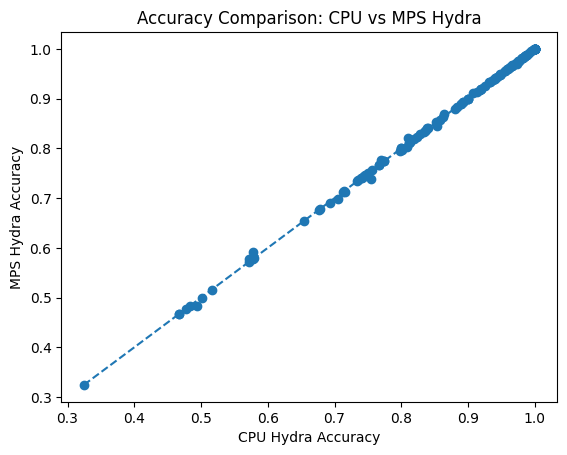

In [33]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df["accuracy_cpu"], df["accuracy_mps"])

# equality line
min_v = min(df["accuracy_cpu"].min(), df["accuracy_mps"].min())
max_v = max(df["accuracy_cpu"].max(), df["accuracy_mps"].max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")

plt.xlabel("CPU Hydra Accuracy")
plt.ylabel("MPS Hydra Accuracy")
plt.title("Accuracy Comparison: CPU vs MPS Hydra")

plt.show()


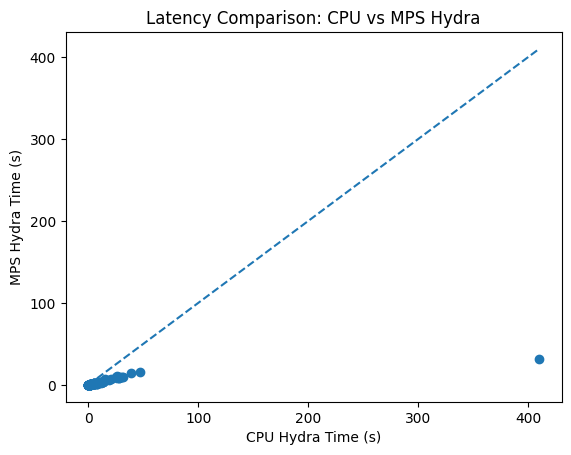

In [34]:
plt.figure()

plt.scatter(df["total_time_cpu"], df["total_time_mps"])

min_v = min(df["total_time_cpu"].min(), df["total_time_mps"].min())
max_v = max(df["total_time_cpu"].max(), df["total_time_mps"].max())

plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")

plt.xlabel("CPU Hydra Time (s)")
plt.ylabel("MPS Hydra Time (s)")
plt.title("Latency Comparison: CPU vs MPS Hydra")

plt.show()


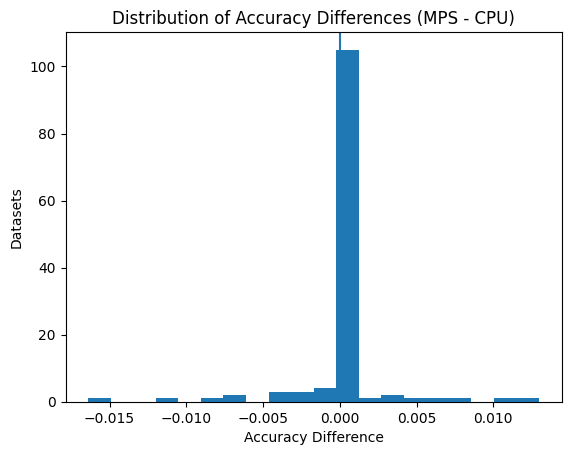

In [35]:
df["accuracy_diff"] = df["accuracy_mps"] - df["accuracy_cpu"]

plt.figure()

plt.hist(df["accuracy_diff"], bins=20)

plt.axvline(0)

plt.title("Distribution of Accuracy Differences (MPS - CPU)")
plt.xlabel("Accuracy Difference")
plt.ylabel("Datasets")

plt.show()


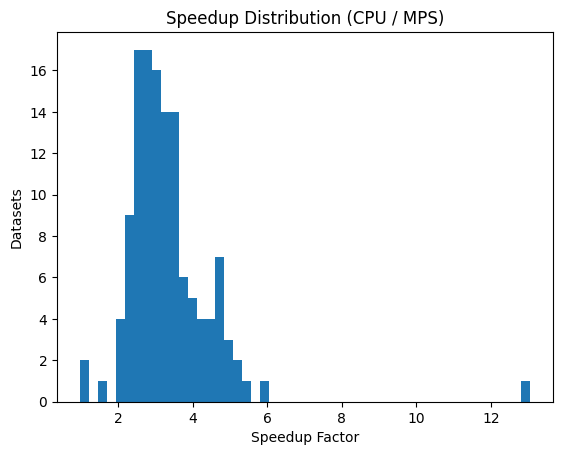

In [39]:
df["speedup"] = df["total_time_cpu"] / df["total_time_mps"]

plt.figure()

plt.hist(df["speedup"], bins=50)


plt.title("Speedup Distribution (CPU / MPS)")
plt.xlabel("Speedup Factor")
plt.ylabel("Datasets")

plt.show()


In [40]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(df["accuracy_cpu"], df["accuracy_mps"])

print("Accuracy Wilcoxon p-value:", p)


Accuracy Wilcoxon p-value: 0.5271827452554574


In [41]:
stat, p = wilcoxon(df["total_time_cpu"], df["total_time_mps"])

print("Latency Wilcoxon p-value:", p)


Latency Wilcoxon p-value: 9.739994101654222e-23


0      1460
1      1460
2       176
3       176
4       500
       ... 
251     900
252     900
253     900
254     426
255     426
Name: series_length, Length: 256, dtype: int64

In [48]:
df["sequence_length"] = summary_results["series_length"] * summary_results["n_test"]

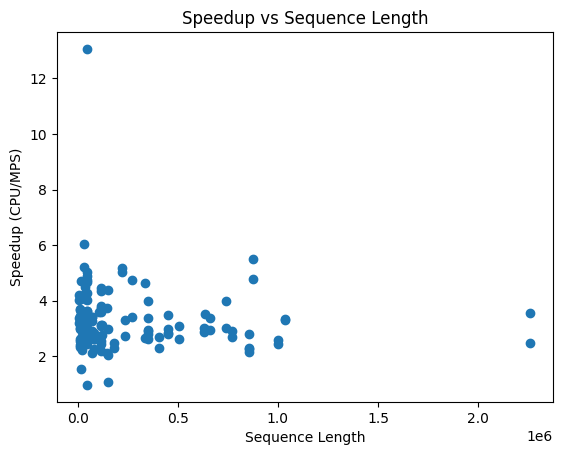

In [49]:
plt.figure()

plt.scatter(df["sequence_length"], df["speedup"])

plt.xlabel("Sequence Length")
plt.ylabel("Speedup (CPU/MPS)")
plt.title("Speedup vs Sequence Length")

plt.show()


In [ ]:
plt.scatter(df["train_size"], df["speedup"])


In [ ]:
differences = hydra_results[["dataset"]].copy()
differences["accuracy"] = hydra_results["accuracy"] - mps_hydra_results["accuracy"]
differences["total_time"] = hydra_results["total_time"] - mps_hydra_results["total_time"]



,dataset,accuracy,total_time
0,ACSF1,0.000000,1.380905
1,Adiac,0.000000,1.008519
2,AllGestureWiimoteX,0.002857,3.502055
3,AllGestureWiimoteY,0.004286,3.468970
4,AllGestureWiimoteZ,0.000000,3.398578
...,...,...,...
123,Wine,0.000000,0.019888
124,WordSynonyms,0.000000,1.637132
125,Worms,0.000000,1.075961
126,WormsTwoClass,0.000000,1.267726


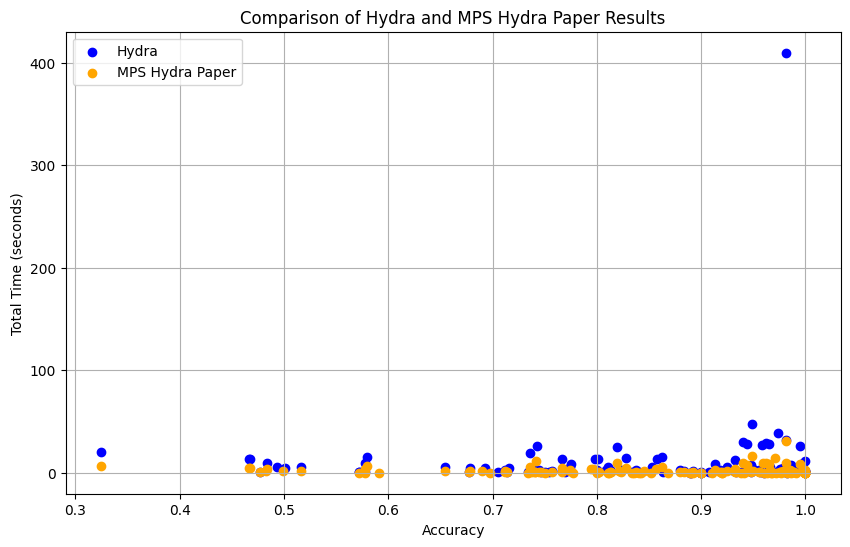

In [30]:
# Plot a scatter plot of the accuracy of each and the total time of each, with the x axis being the accuracy and the y axis being the total time, and color the points by the dataset.
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(hydra_results["accuracy"], hydra_results["total_time"], color="blue", label="Hydra")
plt.scatter(mps_hydra_results["accuracy"], mps_hydra_results["total_time"], color="orange", label="MPS Hydra Paper")
plt.xlabel("Accuracy")
plt.ylabel("Total Time (seconds)")
plt.title("Comparison of Hydra and MPS Hydra Paper Results")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def load_data() -> pd.DataFrame:
    """
    Load the accuracy results into a tidy DataFrame and add derived columns.

    Returns
    -------
    df : pd.DataFrame
        Columns: dataset, mrsqm, hydra, mrsqm_reported, hydra_reported,
                 mrsqm_diff, hydra_diff,
                 my_winner, rep_winner, rank_agrees
    """

    summary_results = pd.read_csv("summary.csv")
    print(summary_results.groupby("model")[["total_time", "accuracy"]].describe().T)

    results_mps_hydra_paper = pd.read_csv("mps_hydra_summary.csv")

    print(results_mps_hydra_paper[["accuracy"]].describe().T)

    mrsqm_accuracy = summary_results[summary_results["model"] == "mrsqm"][["dataset", "accuracy"]]
    mrsqm_accuracy.rename(columns={"accuracy": "mrsqm"}, inplace=True)
    hydra_accuracy = summary_results[summary_results["model"] == "hydra"][["dataset", "accuracy"]]
    hydra_accuracy.rename(columns={"accuracy": "hydra"}, inplace=True)

    mrsqm_reported = results_mrsqm_paper[["Dataset", "MrSQM_SFA_k5"]].copy()
    mrsqm_reported.rename(columns={"MrSQM_SFA_k5": "mrsqm_reported"}, inplace=True)
    mrsqm_reported.rename(columns={"Dataset": "dataset"}, inplace=True)
    hydra_reported = results_hydra_paper[["dataset", "accuracy"]].copy()
    hydra_reported.rename(columns={"accuracy": "hydra_reported"}, inplace=True)

    comparison_df = mrsqm_accuracy.merge(hydra_accuracy, on="dataset").merge(mrsqm_reported, on="dataset").merge(hydra_reported, on="dataset")
    print(comparison_df)

    comparison_df["mrsqm_diff"] = comparison_df["mrsqm"] - comparison_df["mrsqm_reported"]
    comparison_df["hydra_diff"]  = comparison_df["hydra"]  - comparison_df["hydra_reported"]

    def winner(a, b):
        if a > b:   return "mrsqm"
        if b > a:   return "hydra"
        return "tie"

    comparison_df["my_winner"]   = comparison_df.apply(lambda r: winner(r.mrsqm,          r.hydra),          axis=1)
    comparison_df["rep_winner"]  = comparison_df.apply(lambda r: winner(r.mrsqm_reported, r.hydra_reported), axis=1)
    comparison_df["rank_agrees"] = comparison_df["my_winner"] == comparison_df["rep_winner"]
    return comparison_df